# Exploring the platform's data

Everything here is **read-only** over the canonical/derived Parquet stores. Two things to know:

1. **The source trap** — the price store keeps both the original EODHD rows and the DEC-020
   unit-repaired rows. The `prices` view already filters to `source = 'eodhd-gbx'` (the repaired
   data). Query raw files yourself and you must filter, or every bar is doubled.
2. File reads answer *"what does the store contain?"*. Research questions ("what was knowable
   on date X?") must go through the `as_of` APIs — the last section shows how.

Full cookbook: `docs/QUERYING.md`.

In [1]:
from pathlib import Path
import os

# run from the repository root regardless of where jupyter started
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))

from trp.explore import open_console

con = open_console()
con.sql("SELECT table_name FROM information_schema.tables ORDER BY table_name").pl()

table_name
str
"""backtest_daily"""
"""backtest_events"""
"""backtest_rebalances"""
"""dividends"""
"""dividends_original"""
…
"""prices"""
"""prices_original"""
"""securities"""


## SQL in, Polars out

Any query; `.pl()` gives a Polars frame, `.df()` gives pandas.

In [2]:
con.sql("""
    SELECT p.trade_date, p.close
    FROM prices p JOIN securities s USING (security_id)
    WHERE s.name LIKE 'AstraZeneca%' AND p.trade_date >= DATE '2024-01-01'
    ORDER BY p.trade_date
""").pl().tail(5)

trade_date,close
date,"decimal[18,6]"
2026-08-10,11990.000000
2026-08-11,11844.000000
2026-08-12,11702.000000
2026-08-13,11708.000000
2026-08-14,11460.000000


## The momentum run's equity curve

Every backtest run is an immutable record under `data/derived/backtests/<run>/`.

Matplotlib is building the font cache; this may take a moment.


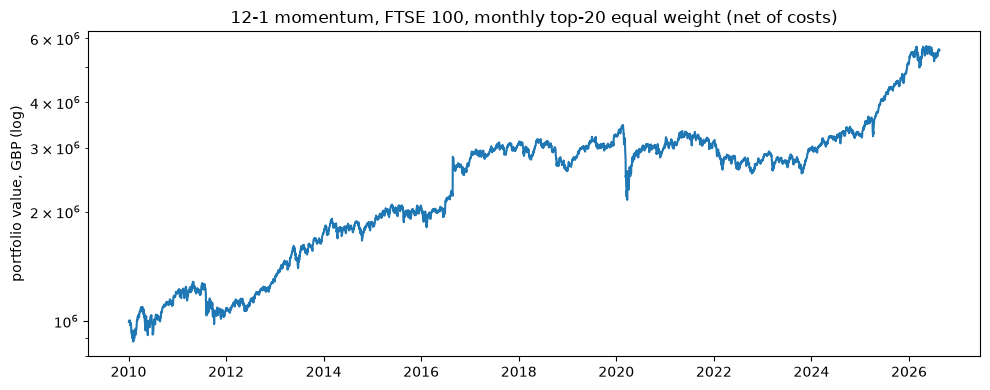

In [3]:
import matplotlib.pyplot as plt

daily = con.sql("""
    SELECT date, value / 100 AS value_gbp
    FROM backtest_daily
    WHERE run = 'momentum-12-1-ftse100-monthly-to-2026-08-17'
    ORDER BY date
""").pl()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily["date"], daily["value_gbp"])
ax.set_yscale("log")
ax.set_title("12-1 momentum, FTSE 100, monthly top-20 equal weight (net of costs)")
ax.set_ylabel("portfolio value, GBP (log)")
fig.tight_layout()

## Survivorship check in one query

The August-2007 FTSE 100 must contain the names that later died.

In [4]:
con.sql("""
    SELECT s.name, m.valid_from, m.valid_to
    FROM membership m JOIN securities s USING (security_id)
    WHERE m.universe = 'FTSE100' AND m.superseded_at IS NULL
      AND DATE '2007-08-15' >= m.valid_from
      AND (m.valid_to IS NULL OR DATE '2007-08-15' < m.valid_to)
      AND s.name SIMILAR TO '(Northern Rock|HBOS|Alliance).*'
    ORDER BY s.name
""").pl()

name,valid_from,valid_to
str,date,date
"""Alliance & Leicester ordinary""",2005-12-19,2008-06-23
"""HBOS ordinary""",2005-12-19,2009-01-19
"""Northern Rock ordinary""",2005-12-19,2007-12-24


## Point-in-time queries (what research code must use)

The SQL above reflects *current* knowledge. To reconstruct what was knowable at a moment,
use the `as_of` APIs — this is the difference between "the store" and "the past".

In [5]:
from datetime import UTC, date, datetime
from trp.config import load_settings
from trp.universe.query import UniverseQuery

query = UniverseQuery(load_settings().canonical_dir / "universes")
members = query.members("FTSE100", date(2015, 6, 30), as_of=datetime(2015, 7, 1, tzinfo=UTC))
len(members)

100